# Bootstrap Aggregation (Bagging)

### Bagging (Bootstrap Aggregating) multiple models ko train karta hai aur unke predictions ko combine karta hai taaki:

#### Accuracy improve ho 
#### Overfitting kam ho 
#### Model stable ho 

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [8]:
from sklearn.datasets import load_wine

df = load_wine()

In [10]:
X = df.data
y = df.target

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [12]:
dtree = DecisionTreeClassifier(random_state = 42)
dtree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [13]:
from sklearn.ensemble import BaggingClassifier

## Create Bagging model

In [15]:
bag = BaggingClassifier(
    estimator = dtree,
    n_estimators = 100,
    random_state = 42
)

## Train the Bagging model

In [20]:
bag.fit(
    X_train,
    y_train
)

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


In [21]:
y_pred = bag.predict(
    X_test
)

In [22]:
accuracy = accuracy_score(
    y_test,
    y_pred
)
print(accuracy)

0.9722222222222222


In [27]:
# Create a list containing different numbers of estimators
# (Decision Trees) to test how the performance of the
# Bagging model changes as the number of estimators increases.

estimator_range = [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]


# Create an empty list to store the accuracy score
# of each Bagging model.

scores = []


# Train and evaluate Bagging models using different
# numbers of estimators.

for n in estimator_range:

    # Create a Bagging classifier with n estimators
    # using Decision Tree as the base model.

    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=n,
        random_state=42
    )

    # Train the Bagging model on the training dataset.

    bag.fit(
        X_train,
        y_train
    )

    # Predict the target values for the test dataset.

    y_pred = bag.predict(
        X_test
    )

    # Calculate the accuracy of the current Bagging model.

    score = accuracy_score(
        y_test,
        y_pred
    )

    # Store the accuracy score in the scores list
    # so that it can be plotted later.

    scores.append(score)

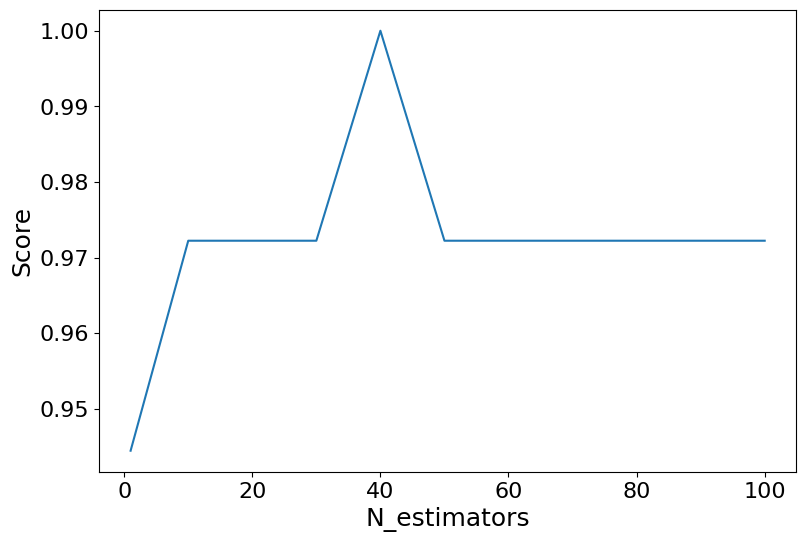

In [28]:
import matplotlib.pyplot as plt

# Create a figure (graph area) with a width of 9
# inches and a height of 6 inches.

plt.figure(figsize=(9, 6))

# Plot the relationship between the number of
# estimators and the corresponding accuracy scores.
#
# X-axis  : Number of estimators (Decision Trees)
# Y-axis  : Accuracy score of the Bagging model

plt.plot(
    estimator_range,
    scores
)

# Set the label for the X-axis.

plt.xlabel(
    "N_estimators",
    fontsize=18
)

# Set the label for the Y-axis.

plt.ylabel(
    "Score",
    fontsize=18
)

# Set the font size of the tick labels
# on both axes for better readability.

plt.tick_params(
    labelsize=16
)

# Display the graph.

plt.show()

In [32]:
len(bag.estimators_)

100

In [34]:
# Access the first Decision Tree
# created by the Bagging model

tree1 = bag.estimators_[0]

print(tree1)

DecisionTreeClassifier(random_state=1952926171)


In [35]:
# Access the second Decision Tree

tree2 = bag.estimators_[1]

print(tree2)

DecisionTreeClassifier(random_state=1761383086)


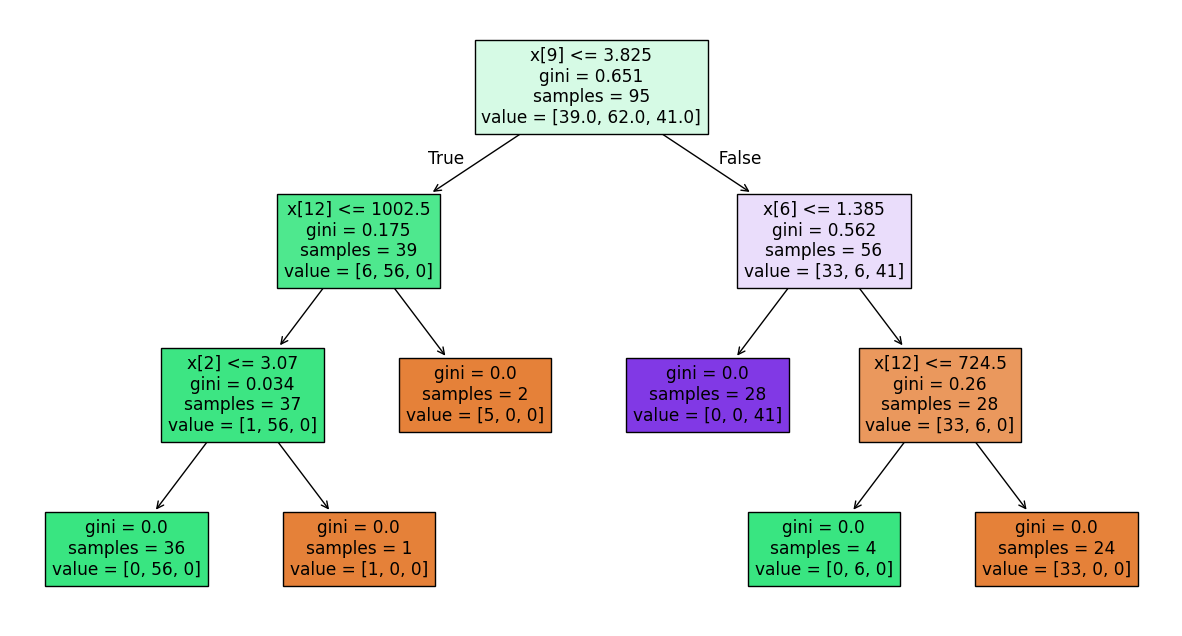

In [37]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Create a figure

plt.figure(figsize=(15, 8))

# Plot the first Decision Tree
# generated by the Bagging model

plot_tree(
    bag.estimators_[0],
    filled=True
)

plt.show()